In [ ]:
import os
import random

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from google.colab import drive

drive.mount('/content/drive')

# Change these paths if necessary

DATASET_DIR = "/content/drive/MyDrive/ml_project"
IMAGE_DIR = os.path.join(DATASET_DIR, "images")
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.csv")


def resolve_image_path(filename, generator):
    candidates = [
        os.path.join(IMAGE_DIR, filename),
        os.path.join(IMAGE_DIR, generator, filename),
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    return candidates[0]


Mounted at /content/drive


In [3]:
metadata = pd.read_csv(METADATA_PATH)

print("Metadata loaded successfully!\n")
metadata.head()

print("="*50)
print("DATASET INFORMATION")
print("="*50)

print(f"Total Images : {len(metadata)}")
print(f"Columns      : {list(metadata.columns)}")

print("\nMissing Values:")
print(metadata.isnull().sum())

Metadata loaded successfully!

DATASET INFORMATION
Total Images : 4800
Columns      : ['filename', 'generator', 'label_binary']

Missing Values:
filename        0
generator       0
label_binary    0
dtype: int64


In [4]:
duplicates = metadata["filename"].duplicated().sum()

print("="*50)
print("DUPLICATE CHECK")
print("="*50)

print(f"Duplicate filenames : {duplicates}")

DUPLICATE CHECK
Duplicate filenames : 0


In [ ]:
missing_files = []

for _, row in metadata.iterrows():
    path = resolve_image_path(row["filename"], row["generator"])
    if not os.path.exists(path):
        missing_files.append((row["filename"], row["generator"]))

print("="*50)
print("FILE EXISTENCE CHECK")
print("="*50)

print(f"Missing files : {len(missing_files)}")

if len(missing_files) > 0:
    print(missing_files[:10])

FILE EXISTENCE CHECK
Missing files : 0


In [6]:
print("="*50)
print("IMAGES PER GENERATOR")
print("="*50)

generator_counts = metadata["generator"].value_counts()

print(generator_counts)

IMAGES PER GENERATOR
generator
Real          800
SD21          800
SDXL          800
SD3           800
DALLE3        800
Midjourney    800
Name: count, dtype: int64


In [7]:
print("="*50)
print("REAL vs FAKE")
print("="*50)

label_counts = metadata["label_binary"].value_counts()

print(label_counts)

REAL vs FAKE
label_binary
1    4000
0     800
Name: count, dtype: int64


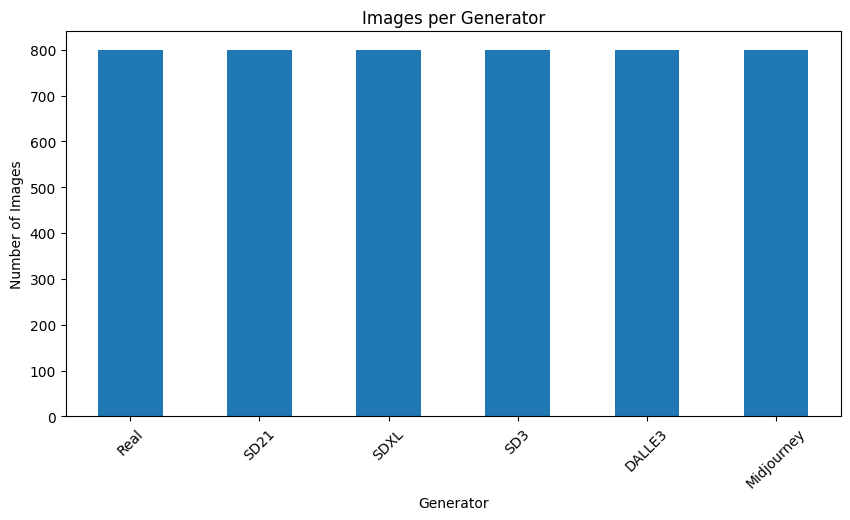

In [8]:
plt.figure(figsize=(10,5))

generator_counts.plot(kind="bar")

plt.title("Images per Generator")
plt.xlabel("Generator")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

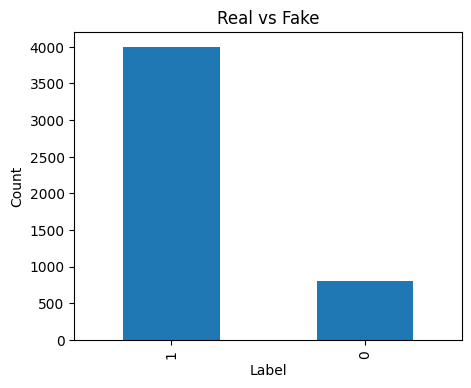

In [9]:
plt.figure(figsize=(5,4))

label_counts.plot(kind="bar")

plt.title("Real vs Fake")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [ ]:
import random
from PIL import Image
import pandas as pd
import os

# Check 100 random images
sample_metadata = metadata.sample(n=min(100, len(metadata)), random_state=42)

sizes = []

for _, row in sample_metadata.iterrows():
    path = resolve_image_path(row["filename"], row["generator"])
    with Image.open(path) as img:
        sizes.append(img.size)

size_df = pd.DataFrame(sizes, columns=["Width", "Height"])

print(size_df.value_counts())

Width  Height
1024   1024      32
270    270       17
768    768       15
436    436       12
640    480        4
       427        4
375    500        2
640    428        2
428    640        1
351    351        1
472    640        1
460    640        1
640    426        1
       425        1
612    612        1
500    391        1
       375        1
640    476        1
       478        1
       481        1
Name: count, dtype: int64


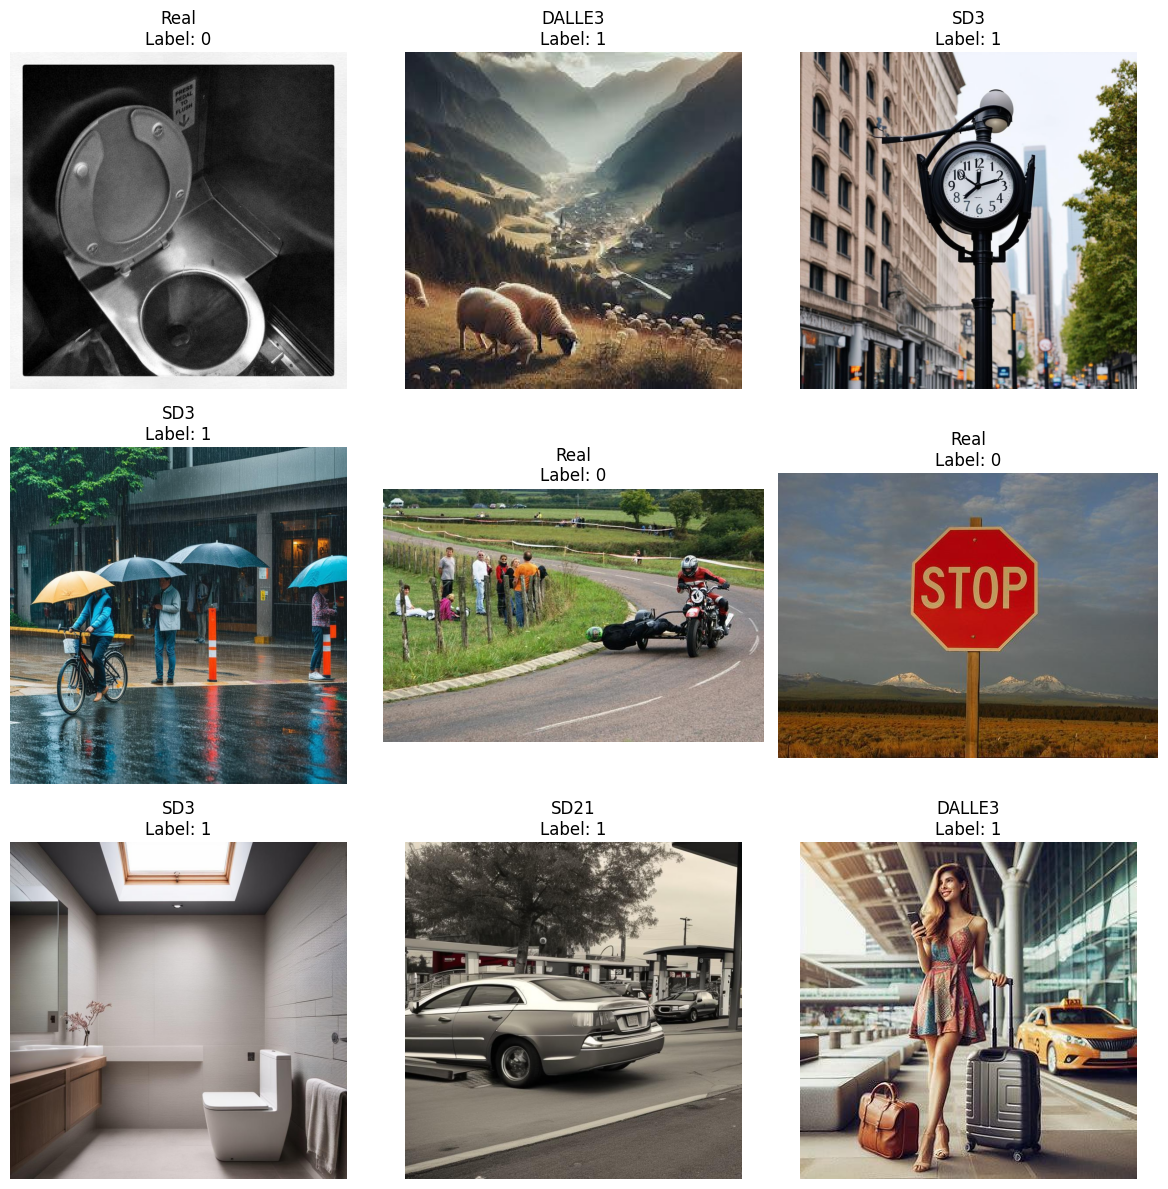

In [ ]:
sample = metadata.sample(9, random_state=42)

plt.figure(figsize=(12,12))

for i, (_, row) in enumerate(sample.iterrows()):
    path = resolve_image_path(row["filename"], row["generator"])
    img = Image.open(path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.title(f'{row["generator"]}\nLabel: {row["label_binary"]}')

    plt.axis("off")

plt.tight_layout()

plt.show()

In [13]:
print("="*60)
print("DATASET VALIDATION SUMMARY")
print("="*60)

print(f"Total Images        : {len(metadata)}")
print(f"Missing Files       : {len(missing_files)}")
print(f"Duplicate Filenames : {duplicates}")
print(f"Generators          : {metadata['generator'].nunique()}")
print(f"Unique Image Sizes  : {len(size_df.value_counts())}")

if len(missing_files)==0 and duplicates==0:
    print("\nDataset validation PASSED")
else:
    print("\nDataset validation requires attention.")

DATASET VALIDATION SUMMARY
Total Images        : 4800
Missing Files       : 0
Duplicate Filenames : 0
Generators          : 6
Unique Image Sizes  : 20

Dataset validation PASSED


In [ ]:
sample = metadata.sample(5, random_state=42)

for _, row in sample.iterrows():
    path = resolve_image_path(row["filename"], row["generator"])
    with Image.open(path) as img:
        print(row["filename"], img.size)

Real_596.jpg (612, 612)
DALLE3_170.jpg (270, 270)
SD3_648.jpg (1024, 1024)
SD3_508.jpg (1024, 1024)
Real_8.jpg (640, 427)
